In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

In [ ]:
# Load the dataset
df = pd.read_csv("../data/customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [74]:
# Check the shape of the dataset
df.shape

(2240, 29)

In [75]:
# Check the columns in the dataset
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [76]:
# checking the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [77]:
# Convert the Dt_Customer column to datetime format
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [78]:
# Check for missing values
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [79]:
# Drop rows with missing values
df = df.dropna()
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [ ]:
# Get summary statistics of the dataset
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,2013-07-10 11:29:27.509025280,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-31 00:00:00,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,NaN,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417


In [81]:
# Get summary statistics of the object columns
df.describe(include=['object'])

,Education,Marital_Status
count,2216,2216
unique,5,8
top,Graduation,Married
freq,1116,857


In [82]:
# check the unique values in the object columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

Education: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Marital_Status: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


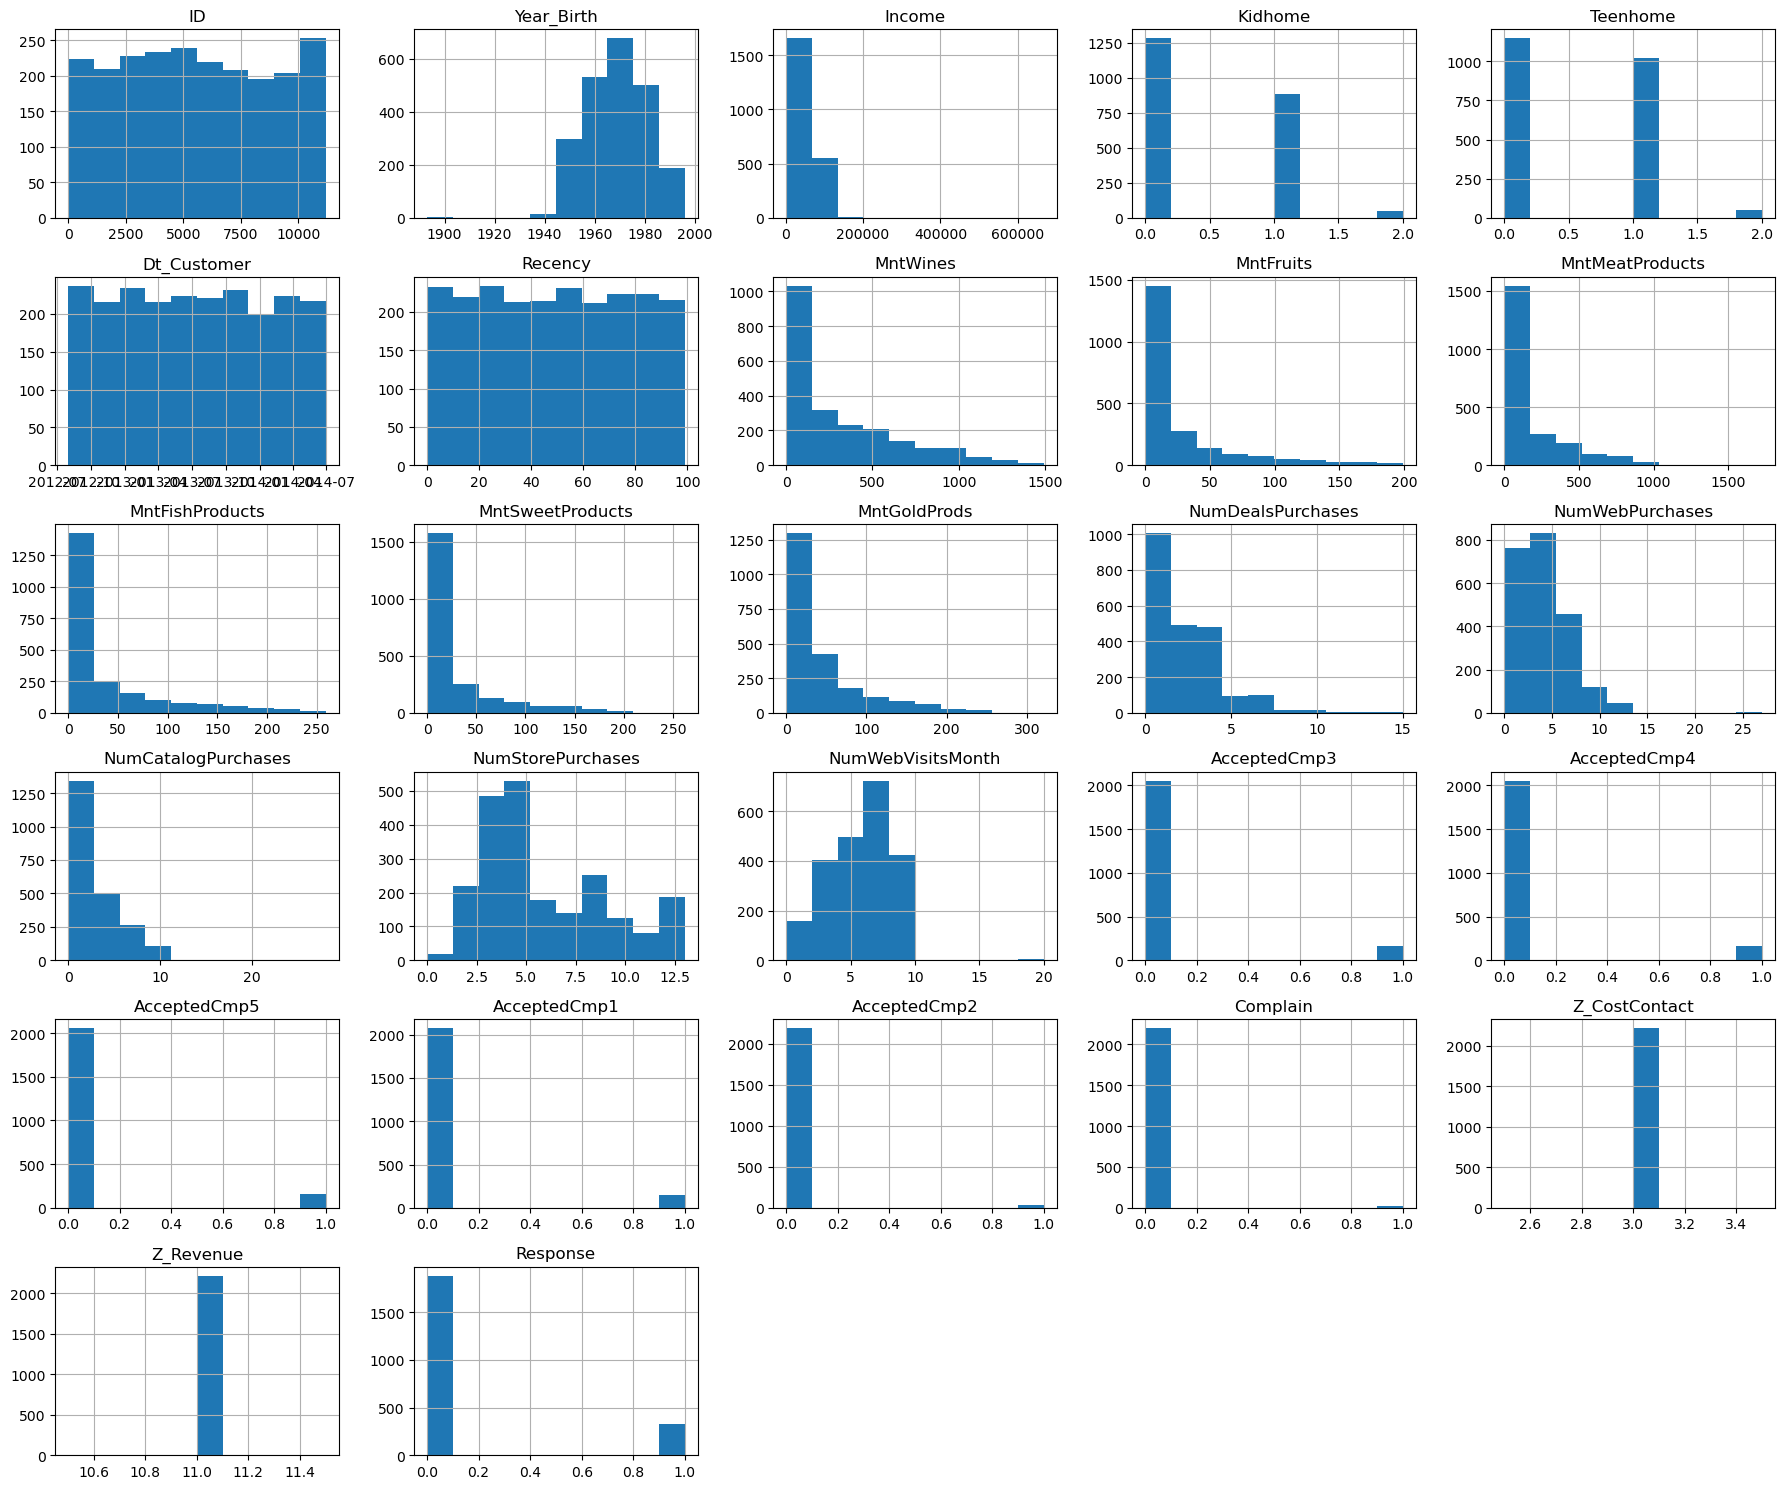

In [83]:
# Check the distribution of the numerical columns
df.hist(figsize=(18, 15))
plt.tight_layout()

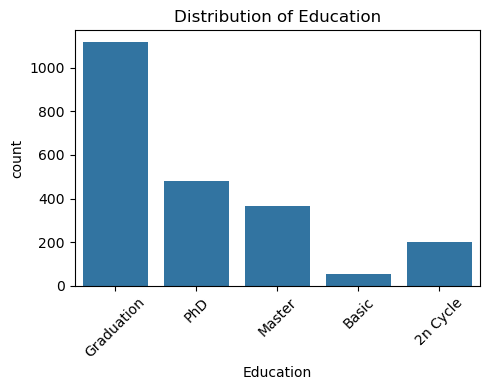

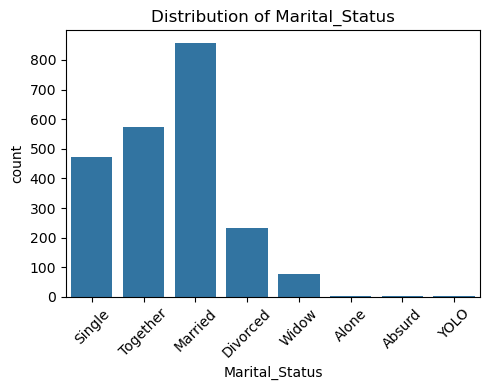

In [84]:
# plot the distribution of the categorical columns and include the count of each category using seaborn
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(5, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [85]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


### Feature Engineering

In [86]:
data = df.copy()

In [87]:
# Create a new column "Age" by calculating the difference between the current year and the Year_Birth column
from datetime import datetime
current_year = datetime.now().year

df["Age"] = current_year - df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45


In [88]:
# Create a new column "Total_Children"
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1


In [89]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='object')

In [90]:
# Create a new column for "Total_Spending"
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# total spending
df["Total_Spending"] = df[spend_cols].sum(axis=1)
df["Total_Spending"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

In [91]:
# create a new column for the number of days since the customer joined
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days
df["Customer_Since"]

0       5003
1       4453
2       4652
3       4479
4       4501
        ... 
2235    4721
2236    4359
2237    4495
2238    4496
2239    4962
Name: Customer_Since, Length: 2216, dtype: int64

### Analysis

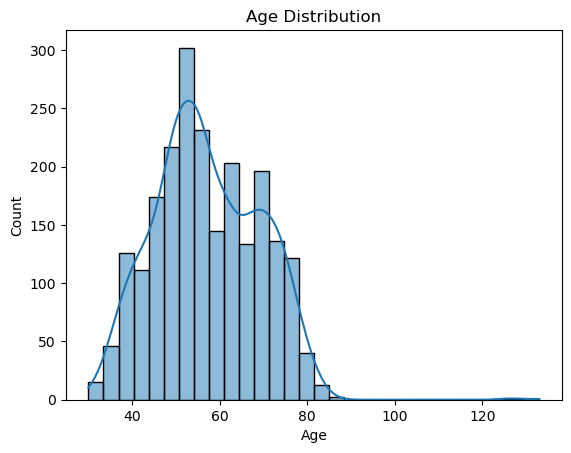

In [92]:
# How is the age distributed?
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

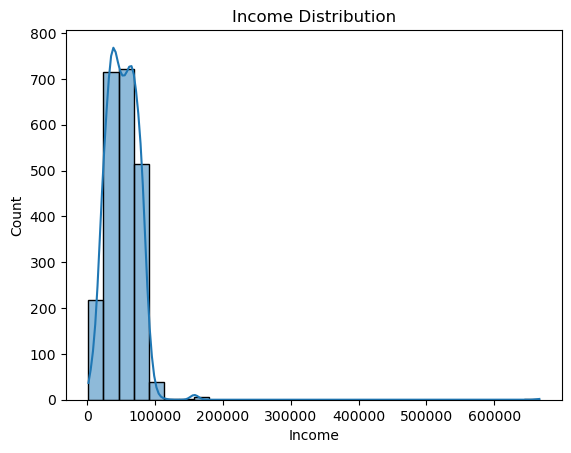

In [93]:
# How is the Income distributed?
sns.histplot(df["Income"], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

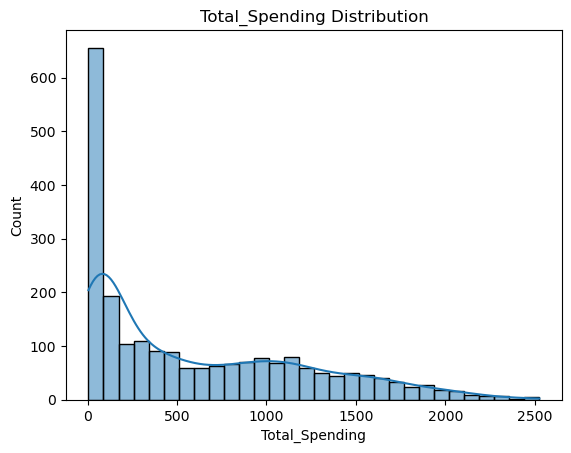

In [94]:
# How is the Total_Spending distributed?
sns.histplot(df["Total_Spending"], bins=30, kde=True)
plt.title("Total_Spending Distribution")
plt.show()

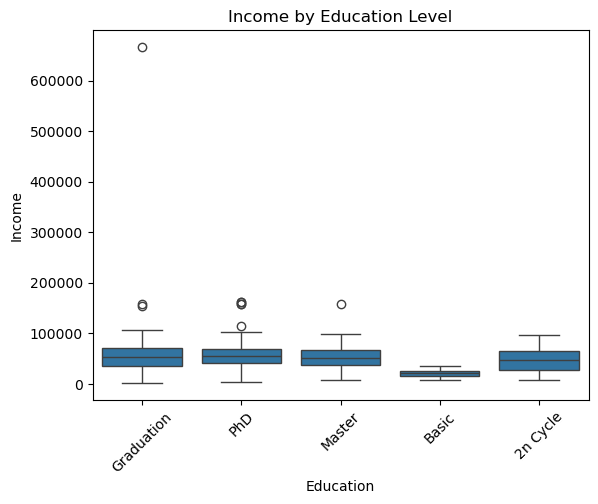

In [95]:
# How is the Income distributed by Education level?
sns.boxplot(x="Education", y="Income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

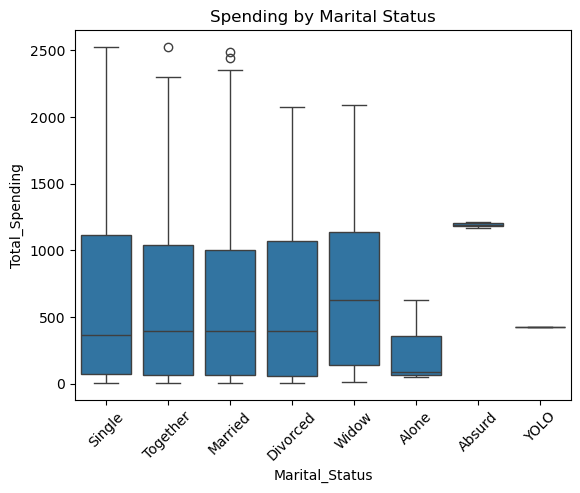

In [96]:
# How is the Total_Spending distributed by Marital Status?
sns.boxplot(x="Marital_Status", y="Total_Spending", data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
plt.show()

In [97]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [98]:
# Compute the correlation matrix for subset of numerical columns
corr_df = df[['Income', 'Age', 'Recency', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', "Total_Children"]]
corr_df.head()

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,Total_Children
0,58138.0,69,58,1617,8,4,0
1,46344.0,72,38,27,1,2,2
2,71613.0,61,26,776,8,10,0
3,26646.0,42,26,53,2,4,1
4,58293.0,45,94,422,5,6,1


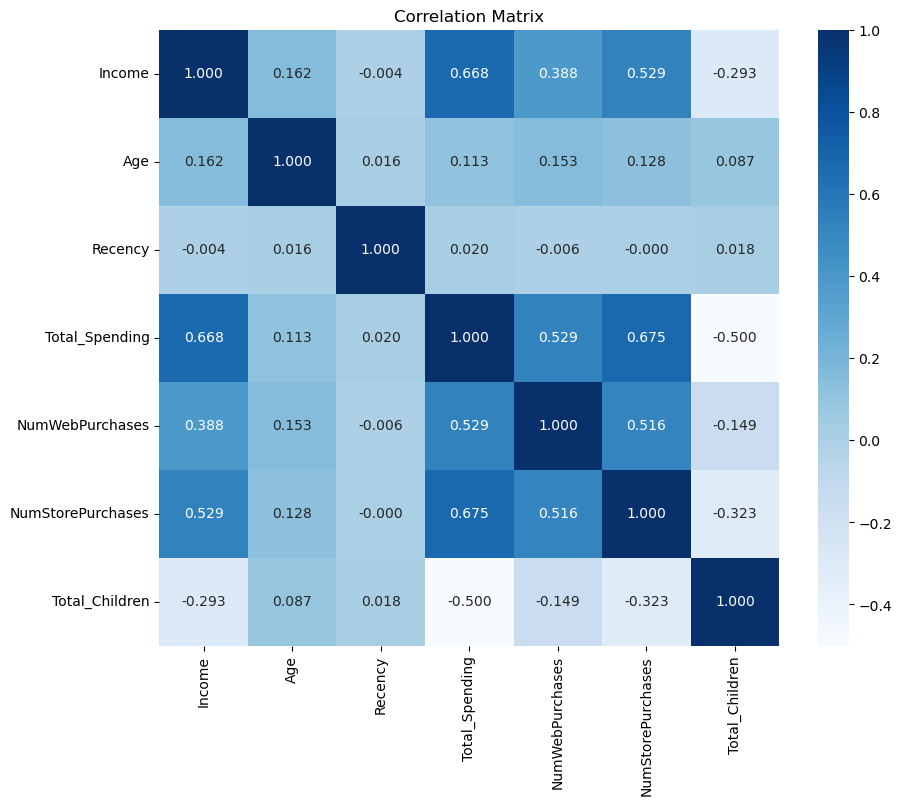

In [99]:
# Compute the correlation matrix and visualize it using a heatmap
corr = corr_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".3f")
plt.title("Correlation Matrix")
plt.show()

In [100]:
# How is the average Income distributed by Education and Marital Status?
pivot_income = df.pivot_table(values="Income", index="Education", columns="Marital_Status", aggfunc="mean")
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education and Marital Status')

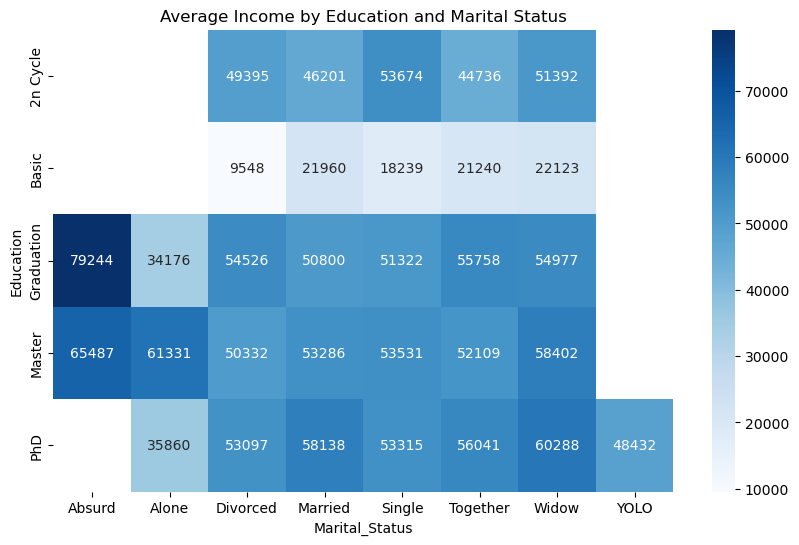

In [101]:
# Visualize the pivot table using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="Blues")
plt.title("Average Income by Education and Marital Status")

In [102]:
# How is the average Total_Spending distributed by Education level?
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

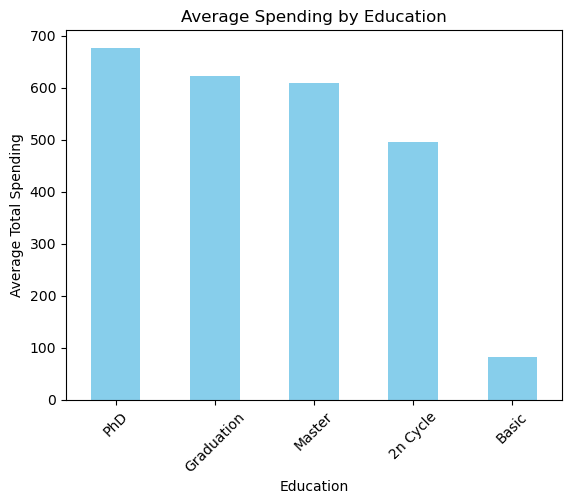

In [103]:
group1.plot(kind="bar", color="skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [104]:
# Create a new column "AcceptedAny" that indicates whether the customer accepted any of the campaigns or not
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)
df["AcceptedAny"]

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: AcceptedAny, Length: 2216, dtype: int64

In [105]:
# Check the unique values in the "AcceptedAny" column
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5], dtype=int64)

In [106]:
# Convert the "AcceptedAny" column to binary (1 if accepted any campaign, 0 otherwise)
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)
df["AcceptedAny"]

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: AcceptedAny, Length: 2216, dtype: int64

In [107]:
# confirm the unique values in the "AcceptedAny" column after conversion
df["AcceptedAny"].unique()

array([1, 0], dtype=int64)

In [108]:
# How is the acceptance rate distributed by Marital Status?
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

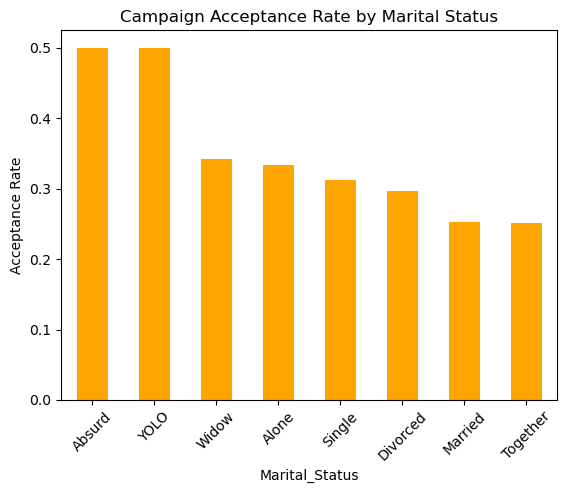

In [109]:
group2.plot(kind="bar", color="orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation=45)
plt.show()

In [110]:
# Create age groups
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)
df["AgeGroup"]

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [111]:
# How is the average Income distributed by Age Group?
group3 = df.groupby("AgeGroup", observed=False)["Income"].mean()
group3

AgeGroup
18-29    10960.500000
30-39    47905.475676
40-49    48057.587649
50-59    50479.321534
60-69    55980.030928
70+      58767.083102
Name: Income, dtype: float64

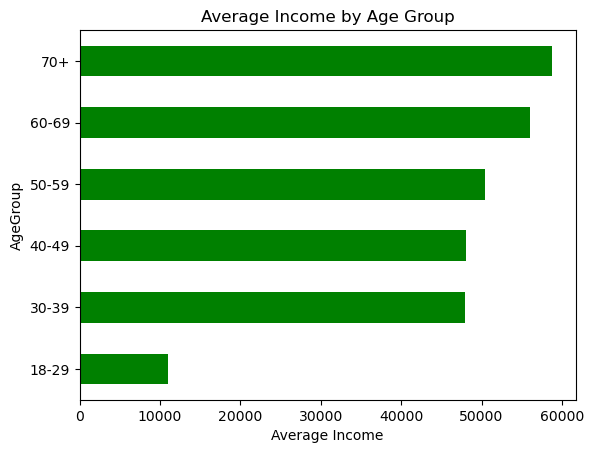

In [112]:
# Visualize the average Income by Age Group
group3.plot(kind="barh", color='green')
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.show()

In [113]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

### Clustering

In [114]:
features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

X = df[features].copy()
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,69,58138.0,1617,8,4,7,58
1,72,46344.0,27,1,2,5,38
2,61,71613.0,776,8,10,4,26
3,42,26646.0,53,2,4,6,26
4,45,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,9,4,5,46
2236,80,64014.0,444,8,5,7,56
2237,45,56981.0,1241,2,13,6,91
2238,70,69245.0,843,6,10,3,8


In [115]:
# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:2]

array([[ 0.98644293,  0.2340627 ,  1.67548812,  1.42855332, -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, -1.12588116, -1.16951781,
        -0.1315745 , -0.38050944]])

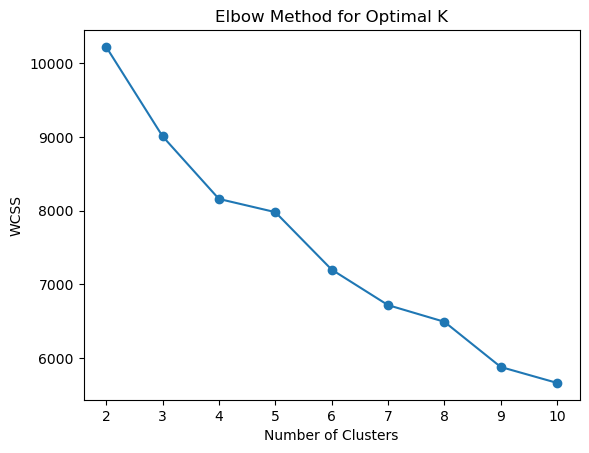

In [116]:
# Elbow method to determine the optimal number of clusters
from sklearn.cluster import KMeans

wcss = []

for n_cluster in range(2, 11):
    kmeans = KMeans(n_clusters=n_cluster)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the WCSS values to visualize the elbow point
plt.plot(range(2, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

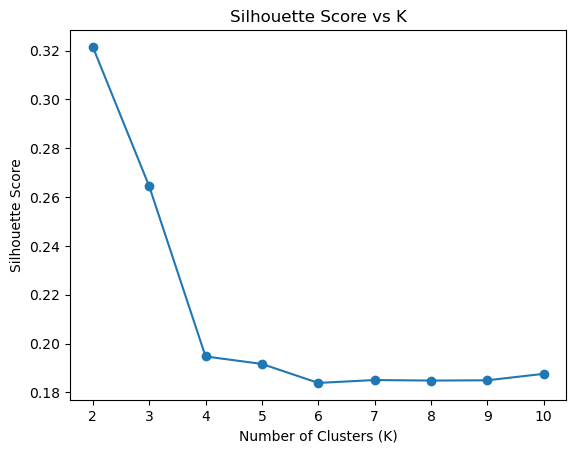

Best K (Silhouette): 2


In [117]:
# Silhouette Score to determine the optimal number of clusters
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = list(range(2, 11))

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure()
plt.plot(k_range, silhouette_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Print best K based on silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
print("Best K (Silhouette):", best_k)

In [118]:
# Cluster stability to determine the optimal number of clusters
def cluster_stability(k, runs=10):
    labels_list = []

    for i in range(runs):
        model = KMeans(n_clusters=k, random_state=i)
        labels = model.fit_predict(X_scaled)
        labels_list.append(labels)

    # compare consistency (simple heuristic)
    consistency = np.mean([
        np.mean(labels_list[0] == labels_list[i])
        for i in range(1, runs)
    ])

    return consistency

k_range = list(range(2, 11))

for k in k_range:
    print(f"K={k}, stability={cluster_stability(k):.3f}")

K=2, stability=0.556
K=3, stability=0.398
K=4, stability=0.279
K=5, stability=0.179
K=6, stability=0.202
K=7, stability=0.187
K=8, stability=0.116
K=9, stability=0.093
K=10, stability=0.087


#### Cluster choice
k = 3

#### Reason for Choosing K = 3

The selection of the optimal number of clusters was based on a combination of the elbow method, silhouette score, stability analysis, and business interpretability.

From the elbow method, the inertia curve shows a smooth and gradual decline without a sharply defined elbow point. This indicates that the dataset does not contain very strong, naturally separated clusters beyond broad groupings. However, there is a noticeable reduction in inertia improvement beyond K = 3, suggesting that increasing the number of clusters beyond this point yields diminishing returns in terms of within-cluster compactness.

From the silhouette analysis, K = 2 achieved the highest score, indicating the strongest separation between clusters. However, the difference between K = 2 and K = 3 is not drastic, and both values show relatively better structure compared to higher K values, where cluster quality consistently declines.

The stability analysis further supports this decision. While K = 2 shows the highest stability, K = 3 maintains a reasonable level of consistency compared to larger K values, which exhibit significant instability and sensitivity to initialization.

Most importantly, from a business perspective, K = 2 is too coarse for actionable customer segmentation. It oversimplifies the customer base into only two groups, limiting marketing insight. K = 3 provides a more meaningful segmentation structure, allowing interpretation of distinct customer groups such as low-value, mid-value, and high-value customers, which is far more useful for targeted marketing strategies and decision-making.

Therefore, K = 3 is selected as the optimal number of clusters because it represents the best trade-off between:

- the elbow method (diminishing returns beyond K = 3)
- the silhouette score (reasonable cluster separation)
- the stability of clustering assignments
- and most importantly, business interpretability and usability

This ensures that the final segmentation is not only statistically sound but also practically valuable for real-world marketing applications.

In [119]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0,1617,5003,1,60-69,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2,27,4453,0,70+,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0,776,4652,0,60-69,1
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1,53,4479,0,40-49,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1,422,4501,0,40-49,0


In [120]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,54.552281,34496.889734,108.768061,2.152091,3.256654,6.486692,49.428707
1,61.201426,59158.762923,842.363636,7.324421,7.718360,6.219251,45.491979
2,58.021559,76784.601990,1257.527363,4.444444,8.456053,2.444444,51.562189


In [121]:
df["Cluster"].value_counts()

Cluster
0    1052
2     603
1     561
Name: count, dtype: int64

In [122]:
# Visualize the clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:, 0], pca_data[:, 1]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0,1617,5003,1,60-69,1,1.107519,-0.211760
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2,27,4453,0,70+,0,-1.336734,0.269839
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0,776,4652,0,60-69,1,1.882277,-1.014161
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1,53,4479,0,40-49,0,-1.784359,-0.704928
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1,422,4501,0,40-49,0,0.020363,1.235265


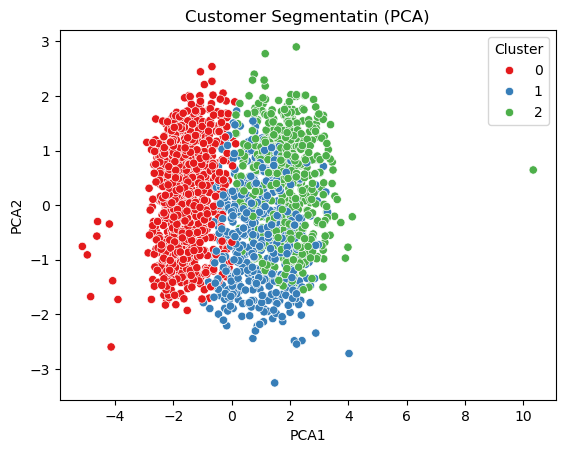

In [123]:
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette="Set1")
plt.title("Customer Segmentatin (PCA)")
plt.show()

In [124]:
# Create a summary table showing the average values of key features for each cluster
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)
global_profile = df.mean(numeric_only=True)

Cluster naming

In [125]:
def compute_cluster_scores(profile, global_profile):
    return {
        "value_score": (
            profile["Total_Spending"] / global_profile["Total_Spending"]
            + profile["Income"] / global_profile["Income"]
        ) / 2,

        "engagement_score": (
            global_profile["Recency"] / profile["Recency"]
        ),

        "digital_score": (
            profile["NumWebPurchases"] / (profile["NumStorePurchases"] + 1)
        )
    }

In [126]:
cluster_labels = {}

for c in cluster_profile.index:
    scores = compute_cluster_scores(
        cluster_profile.loc[c],
        global_profile
    )

    value = scores["value_score"]
    engagement = scores["engagement_score"]
    digital = scores["digital_score"]

    # -------------------------
    # STRICT 1-TO-1 MAPPING
    # -------------------------

    if value >= 1.2 and engagement >= 1.0:
        label = "High-Value Loyal Customers"

    elif value >= 1.2 and engagement < 1.0:
        label = "High-Value At-Risk Customers"

    elif value < 1.2 and digital >= 1.0:
        label = "Digital Growth Customers"

    else:
        label = "Low-Value Traditional Customers"

    cluster_labels[c] = label

In [127]:
df["Cluster_Name"] = df["Cluster"].map(cluster_labels)

print(cluster_labels)

{0: 'Low-Value Traditional Customers', 1: 'High-Value Loyal Customers', 2: 'High-Value At-Risk Customers'}


In [128]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster,PCA1,PCA2,Cluster_Name
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,69,0,1617,5003,1,60-69,1,1.107519,-0.211760,High-Value Loyal Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,72,2,27,4453,0,70+,0,-1.336734,0.269839,Low-Value Traditional Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,61,0,776,4652,0,60-69,1,1.882277,-1.014161,High-Value Loyal Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,42,1,53,4479,0,40-49,0,-1.784359,-0.704928,Low-Value Traditional Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,45,1,422,4501,0,40-49,0,0.020363,1.235265,Low-Value Traditional Customers


In [129]:
df["Cluster_Name"].value_counts()

Cluster_Name
Low-Value Traditional Customers    1052
High-Value At-Risk Customers        603
High-Value Loyal Customers          561
Name: count, dtype: int64

In [130]:
summary = df.groupby(["Cluster", "Cluster_Name"]).agg({
    "Income": "mean",
    "Total_Spending": "mean",
    "Recency": "mean",
    "NumWebPurchases": "mean",
    "NumStorePurchases": "mean",
    "NumWebVisitsMonth": "mean",
    "Total_Children": "mean"
}).round(2)

# summary.to_csv("customer_segments_summary.csv")
summary

,,Income,Total_Spending,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Children
Cluster,Cluster_Name,,,,,,,
0,Low-Value Traditional Customers,34496.89,108.77,49.43,2.15,3.26,6.49,1.25
1,High-Value Loyal Customers,59158.76,842.36,45.49,7.32,7.72,6.22,1.04
2,High-Value At-Risk Customers,76784.60,1257.53,51.56,4.44,8.46,2.44,0.34


### Prediction logic

In [131]:
preds = kmeans.predict(X_scaled)
labels = pd.Series(preds).map(cluster_labels)
print(labels)

0            High-Value Loyal Customers
1       Low-Value Traditional Customers
2            High-Value Loyal Customers
3       Low-Value Traditional Customers
4       Low-Value Traditional Customers
                     ...               
2211         High-Value Loyal Customers
2212         High-Value Loyal Customers
2213       High-Value At-Risk Customers
2214       High-Value At-Risk Customers
2215    Low-Value Traditional Customers
Length: 2216, dtype: object


In [132]:
preds

array([1, 0, 1, ..., 2, 2, 0])

In [133]:
print(df["Cluster_Name"])

0            High-Value Loyal Customers
1       Low-Value Traditional Customers
2            High-Value Loyal Customers
3       Low-Value Traditional Customers
4       Low-Value Traditional Customers
                     ...               
2235         High-Value Loyal Customers
2236         High-Value Loyal Customers
2237       High-Value At-Risk Customers
2238       High-Value At-Risk Customers
2239    Low-Value Traditional Customers
Name: Cluster_Name, Length: 2216, dtype: object


In [136]:
# Features variables
X.columns

Index(['Age', 'Income', 'Total_Spending', 'NumWebPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Recency'],
      dtype='object')